In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical


In [4]:
# 1. Network Architectures
class PolicyNetwork(nn.Module):
    """The Actor: Parameterizes pi_theta(a|s)"""
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, state):
        probs = self.net(state)
        return Categorical(probs)

In [5]:
class ValueNetwork(nn.Module):
    """The Critic (Baseline): Approximates V_w(s)"""
    def __init__(self, state_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, state):
        return self.net(state)

In [6]:
env = gym.make('CartPole-v1')
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

lr_actor = 1e-2
lr_critic = 1e-2
gamma = 0.99
max_episodes = 500

actor = PolicyNetwork(state_dim, action_dim)
critic = ValueNetwork(state_dim)

actor_optimizer = optim.Adam(actor.parameters(), lr=lr_actor)
critic_optimizer = optim.Adam(critic.parameters(), lr=lr_critic)

In [13]:
! pip install gymnasium[classic-control]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 18.1 MB/s eta 0:00:00 0:00:01


Trajectory saved to cartpole_initial.gif (Length: 19 frames)
Episode 0	 Return: 18.0
Episode 20	 Return: 25.0
Episode 40	 Return: 142.0
Episode 60	 Return: 111.0
Episode 80	 Return: 129.0
Episode 100	 Return: 500.0
Episode 120	 Return: 500.0
Episode 140	 Return: 500.0
Episode 160	 Return: 500.0
Episode 180	 Return: 500.0
Episode 200	 Return: 500.0
Episode 220	 Return: 500.0
Episode 240	 Return: 500.0
Episode 260	 Return: 500.0
Episode 280	 Return: 439.0
Episode 300	 Return: 500.0
Episode 320	 Return: 500.0
Episode 340	 Return: 500.0
Episode 360	 Return: 500.0
Episode 380	 Return: 77.0
Episode 400	 Return: 500.0
Episode 420	 Return: 500.0
Episode 440	 Return: 500.0
Episode 460	 Return: 500.0
Episode 480	 Return: 500.0
Trajectory saved to cartpole_final.gif (Length: 501 frames)


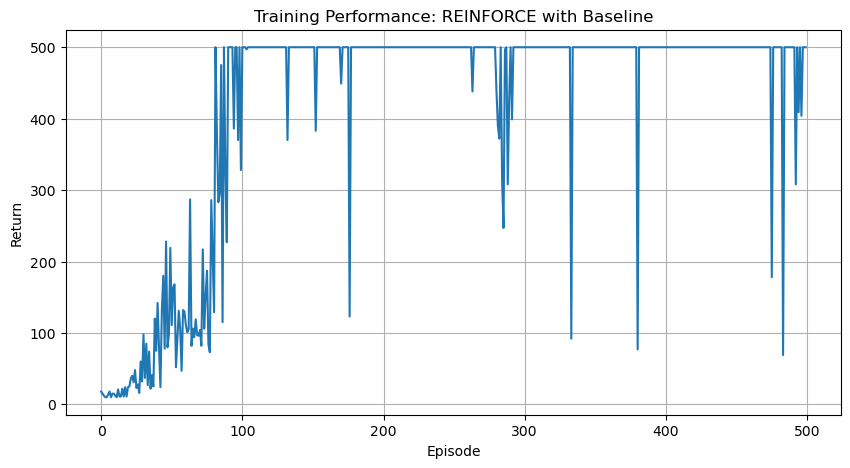

In [14]:
import matplotlib.pyplot as plt

def train():
    # Hyperparameters
    env = gym.make('CartPole-v1')
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n
    
    lr_actor = 1e-2
    lr_critic = 1e-2
    gamma = 0.99
    max_episodes = 500

    actor = PolicyNetwork(state_dim, action_dim)
    critic = ValueNetwork(state_dim)
    
    actor_optimizer = optim.Adam(actor.parameters(), lr=lr_actor)
    critic_optimizer = optim.Adam(critic.parameters(), lr=lr_critic)

    # 1. Record Initial Untrained Policy
    record_policy_gif(actor, "cartpole_initial.gif")
    
    episode_returns = []

    for episode in range(max_episodes):
        state, _ = env.reset()
        
        log_probs = []
        values = []
        rewards = []

        # Trajectory Rollout
        while True:
            state_tensor = torch.FloatTensor(state)
            
            dist = actor(state_tensor)
            value = critic(state_tensor)
            
            action = dist.sample()
            
            next_state, reward, terminated, truncated, _ = env.step(action.item())
            
            log_probs.append(dist.log_prob(action))
            values.append(value)
            rewards.append(reward)
            
            state = next_state
            if terminated or truncated:
                break

        # Calculate Returns (G_t)
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        returns = torch.tensor(returns)

        # Calculate Advantage and Update
        log_probs = torch.stack(log_probs)
        values = torch.stack(values).squeeze()
        
        advantages = returns - values.detach()

        actor_loss = -(log_probs * advantages).mean()
        critic_loss = nn.functional.mse_loss(values, returns)

        actor_optimizer.zero_grad()
        actor_loss.backward()
        actor_optimizer.step()

        critic_optimizer.zero_grad()
        critic_loss.backward()
        critic_optimizer.step()

        # Logging and Tracking
        ep_return = sum(rewards)
        episode_returns.append(ep_return)
        
        if episode % 20 == 0:
            print(f"Episode {episode}\t Return: {ep_return}")

    env.close()
    # 2. Record Final Trained Policy
    record_policy_gif(actor, "cartpole_final.gif")

    # Plotting the learning curve
    plt.figure(figsize=(10, 5))
    plt.plot(episode_returns)
    plt.title('Training Performance: REINFORCE with Baseline')
    plt.xlabel('Episode')
    plt.ylabel('Return')
    plt.grid(True)
    plt.show()

if __name__ == '__main__':
    train()

In [10]:
! pip install imageio

In [11]:
import imageio
import gymnasium as gym
import torch

def record_policy_gif(policy_net, filename, env_id='CartPole-v1', max_steps=500, fps=30):
    """Generates a trajectory rollout and saves it as a GIF."""
    # render_mode='rgb_array' is strictly required to capture visual frames
    env = gym.make(env_id, render_mode='rgb_array')
    state, _ = env.reset()
    frames = []

    # Set network to evaluation mode (disables dropout/batchnorm if present)
    policy_net.eval()

    for _ in range(max_steps):
        frames.append(env.render())
        
        state_tensor = torch.FloatTensor(state)
        with torch.no_grad():
            dist = policy_net(state_tensor)
            # Sampling preserves the stochastic nature of the policy. 
            # Alternatively, use action = torch.argmax(dist.probs) for a deterministic evaluation.
            action = dist.sample()
            
        state, _, terminated, truncated, _ = env.step(action.item())
        
        if terminated or truncated:
            # Capture the terminal state frame
            frames.append(env.render())
            break
            
    env.close()
    
    # Revert to training mode
    policy_net.train()
    
    # Compile and save the accumulated frames
    imageio.mimsave(filename, frames, fps=fps)
    print(f"Trajectory saved to {filename} (Length: {len(frames)} frames)")